# PatchTST RevIN price forecasting -- step 4 (raw OHLC, no volume)

**Step 4 of the experiment ladder: raw OHLC price target (RevIN), volume dropped entirely**
(not a context input, not a training target). This is a same-notebook, same-infra rerun of
the volume-free RevIN result from earlier work on this branch -- that earlier result showed
above-chance directional accuracy (0.53-0.55), but it predates this ladder's exact code
(different notebook, different point in the codebase's history), so it's not a clean
apples-to-apples comparison against steps 3's two volume-included runs. This run closes
that gap: identical architecture/loss/hyperparameters/notebook to
`hf_patchtst_revin_ohlc_global_volume`, with only the volume channel removed.

**Why this matters**: both step-3 variants (RevIN-normalized volume, and volume on a
stable global scale instead) landed at below-chance directional accuracy (0.46-0.48),
while the historical volume-free result was above chance. The working hypothesis is that
volume's mere presence as a joint prediction target -- not how it's scaled -- degrades
price-direction learning, because the shared fused head has to split its capacity/gradient
budget across a 5th output. This run tests that hypothesis directly: same code, volume
just removed.

**Target**: raw OHLC price, RevIN-normalized (Kim et al. 2021 -- learnable per-channel
`affine_weight`/`affine_bias`). No volume channel at all -- `N_CHANNELS = 4` (open, high,
low, close only), same as the original pre-ladder RevIN notebook.

**Kept identical to the rest of this notebook family, for comparability**:
- Data: `steven/data/spy_ohlcv_1h.parquet`, same chronological train/val/test splits.
- `patch_length=7`, `patch_stride=7`, fixed `context_length=MAX_CONTEXT=70`, `HORIZON=3`.
- Model capacity (`d_model=64`, 4 heads, 3 layers) and training hyperparameters
  (`lr=6e-4`, `weight_decay=1e-4`, `batch_size=512`, 20 epochs x 20,000 windows/epoch).
- `channel_attention` swept True/False in one pass, same as steps 1-3.
- No `tanh`/`sigmoid` output bounding (RevIN-normalized values don't have the physical cap
  log-returns do, same as every RevIN variant in this family).

**Also reports the coherence-rate diagnostic** (fraction of test windows where all 3
predicted horizon bars agree on direction) for direct comparison against both step-3
variants (0.81-0.94) and step 2's collapse (0/2397).

**Deferred, same as every other notebook in this family**: the long-only bracket-order
backtest, until a target/volume variant is picked from the forecasting-metrics ladder.


## Colab setup

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv


name, memory.total [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB


In [2]:
import os

REPO_URL = "https://github.com/WoodyChang21/ECE1508_GenAI.git"
BRANCH = "patchtst_ohlcv_mse"
REPO_DIR = "/content/ECE1508_GenAI"   # absolute path -- see note below

if not os.path.isdir(REPO_DIR):
    !git clone -b {BRANCH} {REPO_URL} {REPO_DIR}
else:
    # git -C targets REPO_DIR explicitly rather than `cd X && ...`, so this is correct
    # regardless of the kernel's current working directory when the cell reruns.
    #
    # fetch + checkout {BRANCH} (not just `pull`): REPO_DIR persists across notebook runs
    # within the same Colab VM session, so if an earlier run in this session cloned a
    # DIFFERENT branch (e.g. this VM was previously used for a notebook with an older
    # BRANCH value), a bare `pull` here would just pull more commits onto that stale
    # branch instead of switching -- and the push cell at the bottom would then fail with
    # "src refspec {BRANCH} does not match any", since no local branch by that name would
    # exist to push. Explicitly checking out BRANCH every time this cell runs avoids that.
    !git -C {REPO_DIR} fetch origin
    !git -C {REPO_DIR} checkout {BRANCH}
    !git -C {REPO_DIR} pull origin {BRANCH}

# Absolute path, not "ECE1508_GenAI": os.path.isdir("ECE1508_GenAI") above is checked
# relative to the CURRENT working directory -- on a second run of this cell (after the
# %cd below already moved the kernel into /content/ECE1508_GenAI), that relative check
# looks for /content/ECE1508_GenAI/ECE1508_GenAI, finds nothing, and silently clones a
# second, nested copy of the repo inside the first one instead of pulling it.
%cd {REPO_DIR}


Cloning into '/content/ECE1508_GenAI'...
remote: Enumerating objects: 1073, done.
remote: Counting objects: 100% (585/585), done.
remote: Compressing objects: 100% (430/430), done.
remote: Total 1073 (delta 286), reused 445 (delta 155), pack-reused 488 (from 1)
Receiving objects: 100% (1073/1073), 39.14 MiB | 41.88 MiB/s, done.
Resolving deltas: 100% (487/487), done.
/content/ECE1508_GenAI


In [3]:
# torch is preinstalled on Colab; transformers is the one addition vs. steven's own
# colab_train.ipynb (steven's hand-rolled model has no library dependency for this).
!pip install -q transformers mplfinance pyyaml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.5 MB/s eta 0:00:00


In [4]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## Imports and config

`sys.path` is set up so `from src.data_pipeline import ...` / `from src.losses import ...`
resolve the same way steven's own scripts import them (both insert `steven/` itself onto
the path, not the repo root -- see `steven/src/train_patchtst.py`).

`EXPERIMENT` describes *this run* -- it's what gets echoed into each output JSON's
`"experiment"` block and is the thing to paste into `docs/experiments.md`'s row when logging
the result, so the doc and the actual run config can't drift apart. Update `name`/`description`
each time this notebook is repurposed for a different target/volume/loss variant (per the
experiment ladder: fused-head parity check -> drop volume -> raw-price+volume ->
raw-price-no-volume -> head comparison).


In [5]:
import sys, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from transformers import PatchTSTConfig, PatchTSTModel

# Normalise cwd to the repo root regardless of whether this notebook is opened from
# within steven/ (local Jupyter) or the repo root (Colab, after the clone cell above).
if os.path.basename(os.getcwd()) == 'steven':
    os.chdir('..')
sys.path.insert(0, 'steven')

from src.data_pipeline import build_dataset, WindowSampler, MAX_CONTEXT, HORIZON
# No import of weighted_mse_loss/unpack_y/reconstruct_volume -- volume is dropped
# entirely in this run (see intro markdown), so none of the volume-handling helpers apply.

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

DATA_PATH = 'steven/data/spy_ohlcv_1h.parquet'
OHLC_COLS = ['open', 'high', 'low', 'close']
N_CHANNELS = len(OHLC_COLS)   # 4 -- volume dropped, see intro markdown
CLOSE_IDX = OHLC_COLS.index('close')

# -- Describes this run -- echoed into every output JSON and comparison_metrics/ filename.
# "name" -> comparison_metrics/{name}-channel_attention_{false,true}.json
EXPERIMENT = {
    "name": "hf_patchtst_revin_no_volume",
    "description": (
        "HF PatchTSTModel + RevIN, raw OHLC target, volume dropped entirely (input + "
        "target). Step 4 of the experiment ladder -- same-notebook rerun of the earlier "
        "volume-free RevIN result, to confirm (with identical code/infra to step 3's "
        "two volume-included runs) that dropping volume restores above-chance directional "
        "accuracy."
    ),
    "target": "raw_price_revin_no_volume",
    "include_volume": False,
    "loss_weights": {"note": "unweighted -- single RevIN-normalized MSE over the 4 OHLC channels"},
}

# -- Both settings are trained in one pass -- see the training loop below.
CHANNEL_ATTENTION_SETTINGS = [False, True]

# -- Model hyperparameters -- matched to steven/configs/patchtst.yaml's model block, same
# as every other notebook in this family, for comparable model capacity.
D_MODEL      = 64
NUM_HEADS    = 4
NUM_LAYERS   = 3
DROPOUT      = 0.1
HEAD_DROPOUT = 0.0

# -- Patch structure -- one trading day, non-overlapping.
PATCH_LEN    = 7
PATCH_STRIDE = 7

# -- Training hyperparameters -- same as every other notebook in this family.
LR                      = 6e-4
WEIGHT_DECAY            = 1e-4
BATCH_SIZE              = 512
MAX_EPOCHS              = 20
TRAIN_WINDOWS_PER_EPOCH = 20000
WINDOWS_PER_EVAL_SET    = 3000

plt.rcParams['figure.figsize'] = (14, 4)

# -- Seed control -- reset again per setting in the training loop below, so both
# channel_attention runs get identical weight init, not just identical data order.
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f'EXPERIMENT = {EXPERIMENT}')
print(f'SEED = {SEED}, CHANNEL_ATTENTION_SETTINGS = {CHANNEL_ATTENTION_SETTINGS}')


Device: cuda
EXPERIMENT = {'name': 'hf_patchtst_revin_no_volume', 'description': "HF PatchTSTModel + RevIN, raw OHLC target, volume dropped entirely (input + target). Step 4 of the experiment ladder -- same-notebook rerun of the earlier volume-free RevIN result, to confirm (with identical code/infra to step 3's two volume-included runs) that dropping volume restores above-chance directional accuracy.", 'target': 'raw_price_revin_no_volume', 'include_volume': False, 'loss_weights': {'note': 'unweighted -- single RevIN-normalized MSE over the 4 OHLC channels'}}
SEED = 0, CHANNEL_ATTENTION_SETTINGS = [False, True]


## RevIN + model

**`RevIN`**: a real implementation (mean/std + learnable `affine_weight`/`affine_bias`),
not HF `PatchTSTModel`'s built-in scaler. `fit()` computes per-window, per-channel mean/std
from the **context** only; the same stored stats are reused to normalize the true future
OHLC (for the loss) and denormalize the model's predictions (for evaluation). Covers all
`N_CHANNELS=4` channels here -- no split logic needed, since volume isn't in the picture at
all (unlike step 3's `hf_patchtst_revin_ohlc_global_volume`, which had to route volume
around RevIN separately).

**`PatchTSTOHLCVRevIN`**: `PatchTSTModel` backbone (`scaling=None` -- RevIN is applied
externally instead) + the same fused/flattened head design used throughout this project --
**no `tanh`/`sigmoid` bounding** (RevIN-normalized values don't have the physical cap
log-returns do).


In [6]:
class RevIN(nn.Module):
    """Reversible Instance Normalization (Kim et al. 2021). fit() must be called once
    per batch with the raw context window before normalize()/denormalize() -- both use
    whatever mean/std/affine params were last fit, so they only make sense in that order
    within a single forward pass."""
    def __init__(self, num_channels: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.affine_weight = nn.Parameter(torch.ones(num_channels))
        self.affine_bias = nn.Parameter(torch.zeros(num_channels))
        self.mean = None
        self.std = None

    def fit(self, context: torch.Tensor):
        """context: (bs, T, C). Stores per-window, per-channel mean/std (detached --
        these are window statistics, not something to backprop through)."""
        self.mean = context.mean(dim=1, keepdim=True).detach()
        self.std = (context.var(dim=1, keepdim=True, unbiased=False) + self.eps).sqrt().detach()

    def normalize(self, x: torch.Tensor) -> torch.Tensor:
        x = (x - self.mean) / self.std
        return x * self.affine_weight + self.affine_bias

    def denormalize(self, x: torch.Tensor) -> torch.Tensor:
        x = (x - self.affine_bias) / (self.affine_weight + self.eps ** 2)
        return x * self.std + self.mean


class PatchTSTOHLCVRevIN(nn.Module):
    def __init__(self, config: PatchTSTConfig):
        super().__init__()
        self.revin = RevIN(num_channels=N_CHANNELS)
        self.backbone = PatchTSTModel(config)
        self.head = nn.Linear(N_CHANNELS * config.d_model, N_CHANNELS * HORIZON)
        self.dropout = nn.Dropout(config.head_dropout)

    def forward(self, past_values_raw: torch.Tensor) -> torch.Tensor:
        """past_values_raw: (bs, MAX_CONTEXT, 4) raw OHLC. Returns predicted future OHLC
        in RevIN-*normalized* space (bs, HORIZON, 4) -- caller denormalizes via
        self.revin.denormalize() to get back to real price, or normalizes the true target
        the same way for the loss (see run_epoch below)."""
        self.revin.fit(past_values_raw)
        past_values_norm = self.revin.normalize(past_values_raw)

        base_out = self.backbone(past_values=past_values_norm)
        pooled = base_out.last_hidden_state.mean(dim=2)             # mean-pool across patches: (bs, 4, d_model)
        pooled = self.dropout(pooled)
        raw = self.head(pooled.reshape(pooled.shape[0], -1))         # (bs, N_CHANNELS*HORIZON)

        pred_norm = raw.reshape(-1, HORIZON, N_CHANNELS)
        return pred_norm


def build_model(channel_attention: bool) -> PatchTSTOHLCVRevIN:
    config = PatchTSTConfig(
        num_input_channels=N_CHANNELS,   # 4 (open, high, low, close) -- volume dropped
        context_length=MAX_CONTEXT,      # 70 (fixed, matches every other notebook in this family)
        prediction_length=HORIZON,       # 3
        patch_length=PATCH_LEN,
        patch_stride=PATCH_STRIDE,
        d_model=D_MODEL,
        num_attention_heads=NUM_HEADS,
        num_hidden_layers=NUM_LAYERS,
        # transformers no longer has a single unified "dropout" field on PatchTSTConfig
        # (split into these four sub-layer dropouts, see modeling_patchtst.py) -- broadcasting
        # the same rate to all four keeps this equivalent to a single nn.Dropout(p=dropout).
        attention_dropout=DROPOUT,
        positional_dropout=DROPOUT,
        path_dropout=DROPOUT,
        ff_dropout=DROPOUT,
        head_dropout=HEAD_DROPOUT,
        channel_attention=channel_attention,
        scaling=None,   # RevIN is applied externally instead -- see markdown above
    )
    return PatchTSTOHLCVRevIN(config)


## Data

Reuses `build_dataset`/`WindowSampler` from `steven/src/data_pipeline.py` for the
chronological train/val/test split boundaries and valid-start-index logic, but builds
windows directly from **raw OHLC price** (`df[OHLC_COLS]`) -- no volume column at all this
time, no `build_window()`/return-decomposition, no reconstruction needed at evaluation time
(the model's denormalized output is already real price).

Built **once** here, shared across both `channel_attention` settings in the training loop
below, same as every other notebook in this family.


In [7]:
df, bounds, stats = build_dataset(DATA_PATH)
ohlc = df[OHLC_COLS].to_numpy(dtype=np.float32)   # (N, 4) -- raw price, no normalization yet, no volume

train_sampler = WindowSampler(*bounds['train'])
val_sampler   = WindowSampler(*bounds['val'])
test_sampler  = WindowSampler(*bounds['test'])

print(f'Train rows: {bounds["train"][1] - bounds["train"][0]:,}')
print(f'Val rows  : {bounds["val"][1] - bounds["val"][0]:,}')
print(f'Test rows : {bounds["test"][1] - bounds["test"][0]:,}')


class FixedContextOHLCDataset(Dataset):
    """Every window uses the full MAX_CONTEXT (70 bars); target is the next HORIZON (3)
    bars, both as raw OHLC -- no padding handling needed since ctx_bars == MAX_CONTEXT
    exactly (same fixed-context simplification as every other notebook in this family)."""
    def __init__(self, ohlc: np.ndarray, start_indices: np.ndarray):
        self.ohlc = ohlc
        self.start_indices = start_indices

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, i):
        s = int(self.start_indices[i])
        context = self.ohlc[s : s + MAX_CONTEXT]
        target  = self.ohlc[s + MAX_CONTEXT : s + MAX_CONTEXT + HORIZON]
        return {
            'past_values': torch.from_numpy(context),
            'future_values': torch.from_numpy(target),
        }


def collate(batch: list[dict]) -> dict:
    return {
        'past_values': torch.stack([b['past_values'] for b in batch]),
        'future_values': torch.stack([b['future_values'] for b in batch]),
    }


train_starts_full = train_sampler.valid_starts(MAX_CONTEXT)
val_starts_full    = val_sampler.valid_starts(MAX_CONTEXT)
test_starts_full   = test_sampler.valid_starts(MAX_CONTEXT)
print(f'Valid train starts (ctx=70): {len(train_starts_full):,}')
print(f'Valid val starts (ctx=70)  : {len(val_starts_full):,}')
print(f'Valid test starts (ctx=70) : {len(test_starts_full):,}')

val_rng = np.random.default_rng(SEED)
n_val = min(WINDOWS_PER_EVAL_SET, len(val_starts_full))
val_starts = val_rng.choice(val_starts_full, size=n_val, replace=False)
val_ds = FixedContextOHLCDataset(ohlc, val_starts)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

test_rng = np.random.default_rng(123)   # matches steven/src/evaluate.py's --seed default
n_test = min(3000, len(test_starts_full))
test_starts = test_rng.choice(test_starts_full, size=n_test, replace=False)
test_ds = FixedContextOHLCDataset(ohlc, test_starts)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=collate)


Train rows: 21,042
Val rows  : 3,495
Test rows : 2,469
Valid train starts (ctx=70): 20,970
Valid val starts (ctx=70)  : 3,423
Valid test starts (ctx=70) : 2,397


## Training + evaluation

Trains one model per entry in `CHANNEL_ATTENTION_SETTINGS`, evaluates each on the same
fixed test set, and writes one JSON per setting to `steven/comparison_metrics/`.

**Loss**: plain MSE between predicted and true OHLC, both in RevIN-normalized space (the
true future OHLC is normalized with the *same* context-derived stats the model's
prediction is denormalized with -- see `run_epoch` below).

**Evaluation** reports OHLC MAE/RMSE (denormalized, real $), per-horizon-bar directional
accuracy, and the **coherence rate** (fraction of test windows where all 3 predicted
horizon bars agree on direction) -- for direct comparison against both step-3 volume
variants (0.81-0.94 coherence, 0.46-0.48 dir acc) and step 2's collapse (0/2397 coherence).

**Comparability note**: this model only supports `context_length=70` (steven's "long"
bucket), not his full variable-length curriculum -- so compare against steven's **long**
bucket numbers in `steven/outputs/metrics.json`, not his "overall" (mixed-length) numbers.



training channel_attention_false
epoch  1/20  train_loss=0.897071  val_loss=1.419304
epoch  2/20  train_loss=0.376939  val_loss=0.326944
epoch  3/20  train_loss=0.332618  val_loss=0.248774
epoch  4/20  train_loss=0.309409  val_loss=0.292020
epoch  5/20  train_loss=0.307139  val_loss=0.247587
epoch  6/20  train_loss=0.285142  val_loss=0.215652
epoch  7/20  train_loss=0.269453  val_loss=0.248145
epoch  8/20  train_loss=0.261243  val_loss=0.263541
epoch  9/20  train_loss=0.256378  val_loss=0.209707
epoch 10/20  train_loss=0.243991  val_loss=0.186275
epoch 11/20  train_loss=0.232997  val_loss=0.198472
epoch 12/20  train_loss=0.225154  val_loss=0.216978
epoch 13/20  train_loss=0.215739  val_loss=0.170006
epoch 14/20  train_loss=0.203117  val_loss=0.172157
epoch 15/20  train_loss=0.198844  val_loss=0.165907
epoch 16/20  train_loss=0.193053  val_loss=0.173708
epoch 17/20  train_loss=0.177784  val_loss=0.147150
epoch 18/20  train_loss=0.174991  val_loss=0.137449
epoch 19/20  train_loss=0.1681

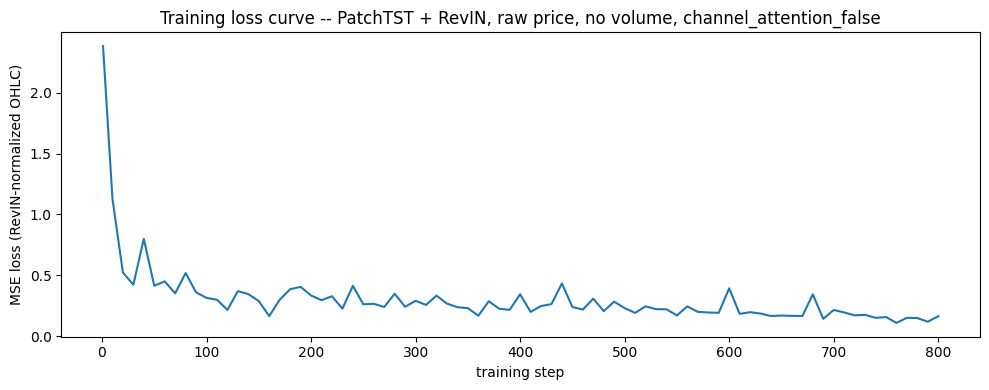

  OHLC MAE / RMSE     : 1.9225 / 3.1103
  dir acc per bar     : 0.5252 / 0.5432 / 0.5428
  coherence rate      : 0.9533  (step 3's two volume-included runs scored 0.81-0.94; step 2's collapse scored 0/2397)
  wrote steven/comparison_metrics/hf_patchtst_revin_no_volume-channel_attention_false.json

training channel_attention_true
epoch  1/20  train_loss=0.819008  val_loss=1.607029
epoch  2/20  train_loss=0.372788  val_loss=0.356367
epoch  3/20  train_loss=0.339387  val_loss=0.263090
epoch  4/20  train_loss=0.315337  val_loss=0.294387
epoch  5/20  train_loss=0.311151  val_loss=0.234253
epoch  6/20  train_loss=0.290924  val_loss=0.231860
epoch  7/20  train_loss=0.272432  val_loss=0.257165
epoch  8/20  train_loss=0.265209  val_loss=0.276604
epoch  9/20  train_loss=0.255746  val_loss=0.282117
epoch 10/20  train_loss=0.244923  val_loss=0.192661
epoch 11/20  train_loss=0.233144  val_loss=0.194986
epoch 12/20  train_loss=0.225119  val_loss=0.234104
epoch 13/20  train_loss=0.216345  val_loss=0.

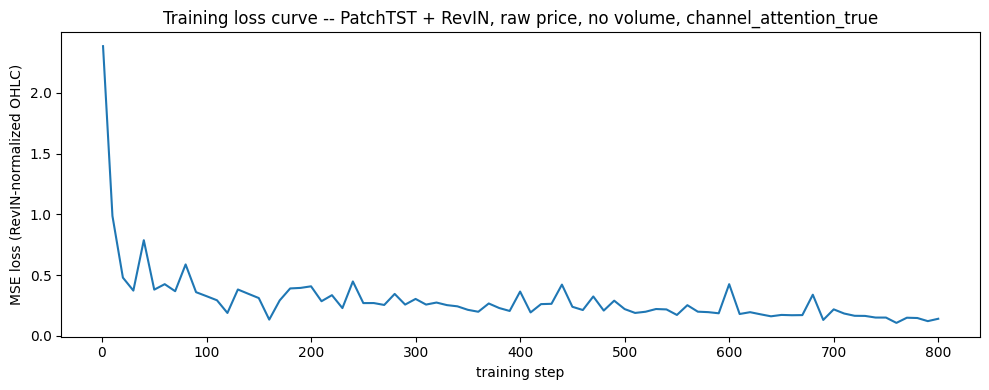

  OHLC MAE / RMSE     : 2.1483 / 3.2997
  dir acc per bar     : 0.5286 / 0.5436 / 0.5486
  coherence rate      : 0.9871  (step 3's two volume-included runs scored 0.81-0.94; step 2's collapse scored 0/2397)
  wrote steven/comparison_metrics/hf_patchtst_revin_no_volume-channel_attention_true.json


In [8]:
def run_epoch(model, loader, optimizer, device, train: bool, loss_history=None, step_holder=None, log_every=10):
    model.train(mode=train)
    total, n = 0.0, 0
    for batch in loader:
        past_values = batch['past_values'].to(device)
        future_values = batch['future_values'].to(device)

        with torch.set_grad_enabled(train):
            pred_norm = model(past_values)
            # RevIN.fit() was just called inside model() using this batch's context, so
            # model.revin.normalize() here uses the matching context-derived stats to put
            # the true target in the same normalized space the loss is computed in.
            true_norm = model.revin.normalize(future_values)
            loss = F.mse_loss(pred_norm, true_norm)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if step_holder is not None:
                step_holder[0] += 1
                if loss_history is not None and (step_holder[0] == 1 or step_holder[0] % log_every == 0):
                    loss_history.append((step_holder[0], float(loss.item())))

        bs = past_values.shape[0]
        total += loss.item() * bs
        n += bs
    return {'loss': total / n}


def mae_rmse(pred: np.ndarray, true: np.ndarray) -> tuple[float, float]:
    diff = pred - true
    return float(np.mean(np.abs(diff))), float(np.sqrt(np.mean(diff ** 2)))


def evaluate(model) -> dict:
    model.eval()
    all_true, all_pred, all_close0 = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            pv = batch['past_values'].to(DEVICE)
            fv = batch['future_values'].to(DEVICE)
            pred_norm = model(pv)
            pred_price = model.revin.denormalize(pred_norm)   # back to real price -- no reconstruct_prices needed
            all_true.append(fv.cpu().numpy())
            all_pred.append(pred_price.cpu().numpy())
            all_close0.append(pv[:, -1, CLOSE_IDX].cpu().numpy())   # last context bar's real close

    true_ohlc = np.concatenate(all_true)     # (n, 3, 4) real [open,high,low,close]
    pred_ohlc = np.concatenate(all_pred)     # (n, 3, 4) predicted
    close_0 = np.concatenate(all_close0)     # (n,)
    n = len(true_ohlc)

    ohlc_mae, ohlc_rmse = mae_rmse(pred_ohlc, true_ohlc)

    true_close_sign = np.sign(true_ohlc[:, :, CLOSE_IDX] - close_0[:, None])
    pred_close_sign = np.sign(pred_ohlc[:, :, CLOSE_IDX] - close_0[:, None])
    dir_acc = (true_close_sign == pred_close_sign).mean(axis=0)

    # Coherence check -- see markdown above.
    coherent_up = (pred_close_sign > 0).all(axis=1)
    coherent_down = (pred_close_sign < 0).all(axis=1)
    coherence_rate = float((coherent_up | coherent_down).mean())

    return {
        'n_windows': n,
        'ohlc_mae': ohlc_mae,
        'ohlc_rmse': ohlc_rmse,
        'directional_accuracy': dir_acc.tolist(),
        'coherence_rate': coherence_rate,
    }


os.makedirs('steven/comparison_metrics', exist_ok=True)
results = {}

for channel_attention in CHANNEL_ATTENTION_SETTINGS:
    setting_key = f'channel_attention_{str(channel_attention).lower()}'
    print(f'\n{"="*70}\ntraining {setting_key}\n{"="*70}')

    # Reset the seed per setting so both runs get identical weight init/dropout draws --
    # data order is already independent of global RNG state (np.random.default_rng(SEED+epoch)
    # below), but model init/dropout use torch's global RNG, which would otherwise have
    # already been advanced by whichever setting trained first.
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = build_model(channel_attention).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    loss_history = []
    step_holder = [0]
    best_val_loss = float('inf')

    for epoch in range(MAX_EPOCHS):
        train_rng = np.random.default_rng(SEED + epoch)
        n_train = min(TRAIN_WINDOWS_PER_EPOCH, len(train_starts_full))
        train_starts = train_rng.choice(train_starts_full, size=n_train, replace=False)
        train_ds = FixedContextOHLCDataset(ohlc, train_starts)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)

        train_metrics = run_epoch(model, train_loader, optimizer, DEVICE, train=True,
                                   loss_history=loss_history, step_holder=step_holder)
        val_metrics = run_epoch(model, val_loader, optimizer, DEVICE, train=False)

        print(f'epoch {epoch+1:2d}/{MAX_EPOCHS}  '
              f'train_loss={train_metrics["loss"]:.6f}  val_loss={val_metrics["loss"]:.6f}')

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']

    print(f'done ({setting_key}). best val_loss={best_val_loss:.6f}')

    fig, ax = plt.subplots(figsize=(10, 4))
    steps, losses = zip(*loss_history)
    ax.plot(steps, losses)
    ax.set_xlabel('training step')
    ax.set_ylabel('MSE loss (RevIN-normalized OHLC)')
    ax.set_title(f'Training loss curve -- PatchTST + RevIN, raw price, no volume, {setting_key}')
    plt.tight_layout()
    plt.show()

    eval_metrics = evaluate(model)
    print(f'  OHLC MAE / RMSE     : {eval_metrics["ohlc_mae"]:.4f} / {eval_metrics["ohlc_rmse"]:.4f}')
    dir_acc = eval_metrics['directional_accuracy']
    print(f'  dir acc per bar     : {dir_acc[0]:.4f} / {dir_acc[1]:.4f} / {dir_acc[2]:.4f}')
    print(f'  coherence rate      : {eval_metrics["coherence_rate"]:.4f}  '
          f'(step 3\'s two volume-included runs scored 0.81-0.94; step 2\'s collapse scored 0/2397)')

    output = {
        'experiment': {**EXPERIMENT, 'channel_attention': channel_attention, 'seed': SEED},
        'best_val_loss': best_val_loss,
        **eval_metrics,
    }
    results[setting_key] = output

    out_path = f'steven/comparison_metrics/{EXPERIMENT["name"]}-{setting_key}.json'
    with open(out_path, 'w') as f:
        json.dump(output, f, indent=2)
    print(f'  wrote {out_path}')


## Results summary

In [9]:
print(f'{"setting":<26} {"OHLC RMSE":>10} {"dir acc (bar1/2/3)":>22} {"coherence":>10}')
for setting_key, r in results.items():
    da = r['directional_accuracy']
    print(f'{setting_key:<26} {r["ohlc_rmse"]:>10.4f} '
          f'{da[0]:>6.4f}/{da[1]:.4f}/{da[2]:.4f}  {r["coherence_rate"]:>9.4f}')


setting                     OHLC RMSE     dir acc (bar1/2/3)  coherence
channel_attention_false        3.1103 0.5252/0.5432/0.5428     0.9533
channel_attention_true         3.2997 0.5286/0.5436/0.5486     0.9871


## Caveats and recommended next steps

- **Compare directly against step 3's two volume-included runs** (both landed at
  0.46-0.48 dir acc, 0.81-0.94 coherence) -- if this run's dir acc is meaningfully above
  chance (like the historical 0.53-0.55 result), that confirms volume's presence as a joint
  target (not its normalization) is what degrades price-direction learning. If this run is
  *also* below chance, the mechanism hypothesis is wrong and something else changed between
  the historical run and this ladder's code/data/seed.
- **One seed per setting.** `CHANNEL_ATTENTION_SETTINGS` controls which settings get
  trained in this pass -- both by default.
- **No output bounding at all** -- unlike the return-based variants' `MAX_LOG_RETURN` cap,
  nothing currently stops a wild RevIN-denormalized prediction if training is unstable or
  undertrained.
- **Fixed context (70 bars) vs. steven's variable-length curriculum**, same simplification
  as every other notebook in this family.
- **No backtest yet** -- deferred until a target/volume variant is picked from the ladder;
  if this run confirms above-chance directional accuracy, it's the first real backtest
  candidate among the raw-price RevIN variants.
- **`evaluate.py` does NOT support this checkpoint shape** -- this notebook computes its
  own metrics inline instead, same as every other notebook in this family.
- **Reusing this notebook for step 5** (head comparison, once a target/volume combo is
  picked from steps 1-4): update `EXPERIMENT["name"]`/`["description"]` and swap in
  whichever head design is being compared -- don't fork a new notebook file.


## Commit + push results

Same pattern as `steven/colab_train.ipynb`'s own commit/push cells -- reused here so every
experiment notebook that runs on a fresh Colab VM handles git auth the same way.


In [10]:
# Fresh Colab VM has no git identity configured -- needed for `commit` to work at all.
# Only sets it for this local clone (no --global), harmless to commit/share.
!git -C {REPO_DIR} config user.email "woodychang891121@gmail.com"
!git -C {REPO_DIR} config user.name "WoodyChang21"

commit_msg = f"chore(model): log {EXPERIMENT['name']} comparison_metrics from this Colab run"

!git add steven/comparison_metrics
!git status
!git commit -m {commit_msg!r}


On branch patchtst_ohlcv_mse
Your branch is up to date with 'origin/patchtst_ohlcv_mse'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   steven/comparison_metrics/hf_patchtst_revin_no_volume-channel_attention_false.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_no_volume-channel_attention_true.json

[patchtst_ohlcv_mse 5221779] chore(model): log hf_patchtst_revin_no_volume comparison_metrics from this Colab run
 2 files changed, 46 insertions(+)
 create mode 100644 steven/comparison_metrics/hf_patchtst_revin_no_volume-channel_attention_false.json
 create mode 100644 steven/comparison_metrics/hf_patchtst_revin_no_volume-channel_attention_true.json


In [11]:
import getpass

# Fresh Colab VM has no stored GitHub credentials, so a plain `git push` over HTTPS
# can't authenticate. Prompting interactively (getpass masks it, and it's never written
# into this notebook's saved source/outputs) instead of hardcoding a token in a cell --
# a hardcoded token would get committed into git history the moment this notebook is
# pushed, which is a real credential leak. Needs a GitHub Personal Access Token with
# `repo` scope: https://github.com/settings/tokens
token = getpass.getpass("GitHub Personal Access Token: ")
push_url = f"https://{token}@github.com/WoodyChang21/ECE1508_GenAI.git"
!git -C {REPO_DIR} push {push_url} {BRANCH}
del token, push_url  # don't leave it sitting in a notebook-visible variable longer than needed


Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 12 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 1.19 KiB | 1.19 MiB/s, done.
Total 6 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 3 local objects.
To https://github.com/WoodyChang21/ECE1508_GenAI.git
   f1ad007..5221779  patchtst_ohlcv_mse -> patchtst_ohlcv_mse
